# Energy-Conserving Decomposition Ablation Studies

This notebook analyzes and visualizes the results from all ablation experiments for the energy-conserving unitary decomposition algorithm from Bai & Marvian (arXiv:2309.11051).

## Overview

We conduct five key ablation studies:

1. **Symmetry-preserving vs standard decomposition**: Compare energy-conserving decomposition against standard transpilation
2. **Ancilla vs non-energy-conserving implementations**: Compare ancilla-based energy-conserving gates (SWAP, CCZ) vs standard implementations
3. **Native vs generic entanglers**: Compare native √iSWAP/XY gates vs transpiled CX-based gates
4. **Angle discretization**: Study the impact of discretizing rotation angles to a fixed grid
5. **Geometry/topology**: Compare all-to-all vs linear chain connectivity

## Setup

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Set plotting style
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Define results directory
RESULTS_DIR = Path('../results')

In [2]:
# Helper function to load results
def load_results(filename: str) -> dict:
    """Load results from JSON file."""
    filepath = RESULTS_DIR / filename
    if not filepath.exists():
        print(f"Warning: {filepath} does not exist. Please run the ablation script first.")
        return None
    
    with open(filepath, 'r') as f:
        return json.load(f)

# Helper function to extract aggregated statistics
def extract_aggregated(results: dict, metric: str, variant: str = None) -> tuple:
    """Extract means and stds for a metric across n_qubits."""
    if results is None:
        return None, None, None
    
    aggregated = results.get('aggregated_statistics', {})
    n_qubits_list = sorted([int(k) for k in aggregated.keys()])
    
    means = []
    stds = []
    
    for n in n_qubits_list:
        data = aggregated[str(n)]
        if variant:
            data = data.get(variant, {})
        
        metric_data = data.get(metric, {})
        means.append(metric_data.get('mean', 0))
        stds.append(metric_data.get('std', 0))
    
    return n_qubits_list, means, stds

## 1. Symmetry-Preserving vs Standard Decomposition

This section compares energy-conserving decomposition against standard transpilation for the same random energy-conserving unitaries.

In [3]:
# Load results
sym_vs_std = load_results('symmetry_vs_standard.json')

if sym_vs_std:
    print("Loaded symmetry_vs_standard results")
    print(f"Parameters: {sym_vs_std['parameters']}")

Loaded symmetry_vs_standard results
Parameters: {'n_qubits_list': [3, 4, 5], 'n_trials': 30, 'seed': 1234}


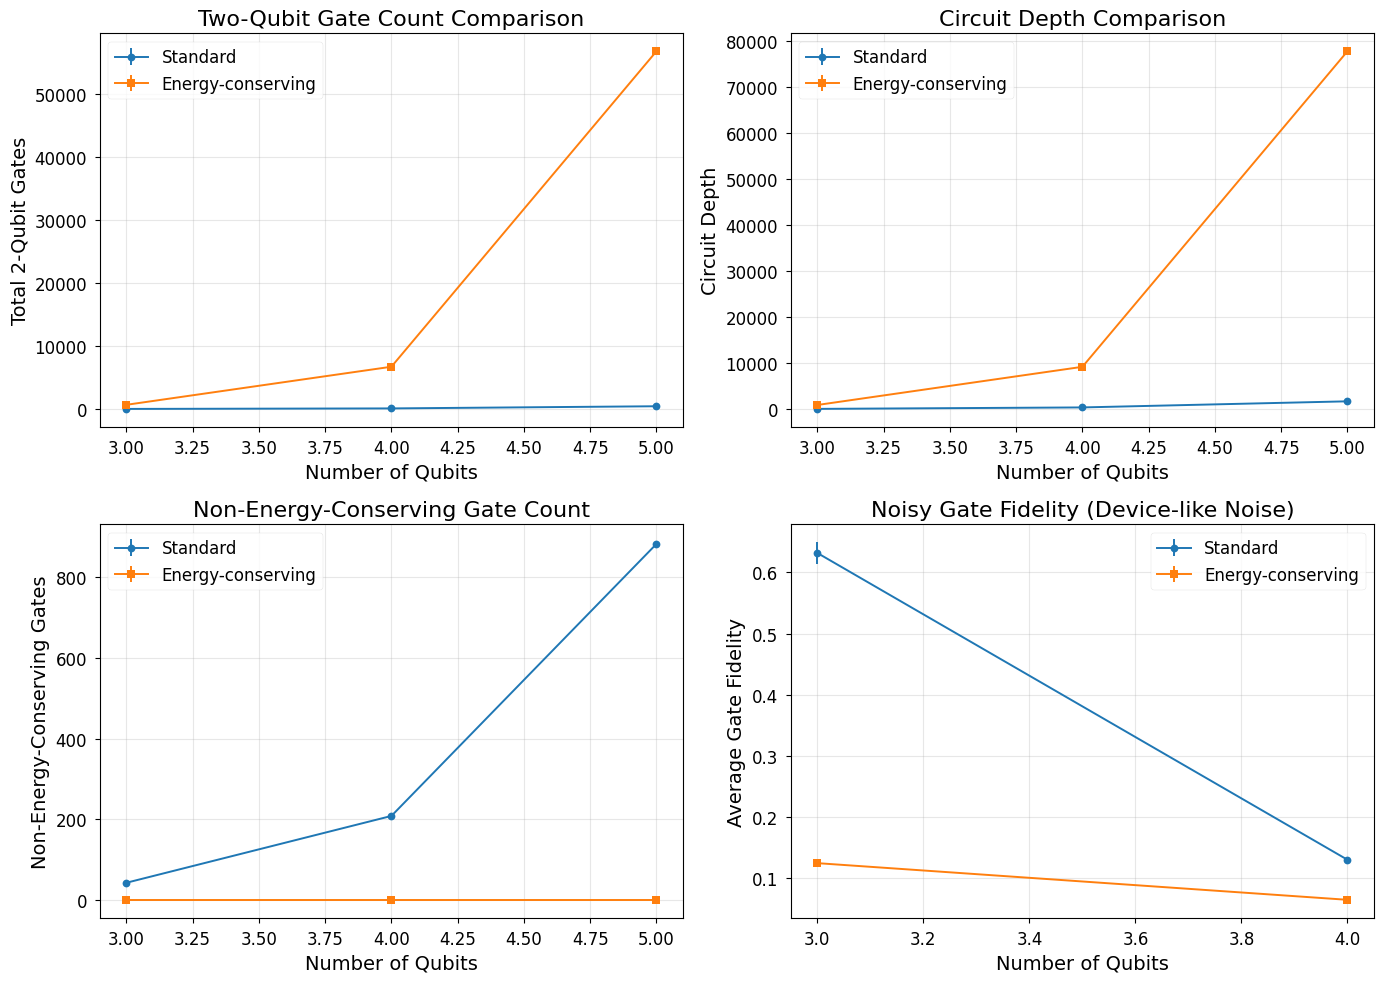

In [4]:
# Plot gate counts comparison
if sym_vs_std:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Total 2q gates
    ax = axes[0, 0]
    n_qubits, means_std, stds_std = extract_aggregated(sym_vs_std, 'total_2q', 'standard')
    _, means_sym, stds_sym = extract_aggregated(sym_vs_std, 'total_2q', 'energy_conserving')
    
    ax.errorbar(n_qubits, means_std, yerr=stds_std, marker='o', label='Standard', capsize=5)
    ax.errorbar(n_qubits, means_sym, yerr=stds_sym, marker='s', label='Energy-conserving', capsize=5)
    ax.set_xlabel('Number of Qubits')
    ax.set_ylabel('Total 2-Qubit Gates')
    ax.set_title('Two-Qubit Gate Count Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Circuit depth
    ax = axes[0, 1]
    _, means_std, stds_std = extract_aggregated(sym_vs_std, 'depth', 'standard')
    _, means_sym, stds_sym = extract_aggregated(sym_vs_std, 'depth', 'energy_conserving')
    
    ax.errorbar(n_qubits, means_std, yerr=stds_std, marker='o', label='Standard', capsize=5)
    ax.errorbar(n_qubits, means_sym, yerr=stds_sym, marker='s', label='Energy-conserving', capsize=5)
    ax.set_xlabel('Number of Qubits')
    ax.set_ylabel('Circuit Depth')
    ax.set_title('Circuit Depth Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Non-conserving gates
    ax = axes[1, 0]
    _, means_std, stds_std = extract_aggregated(sym_vs_std, 'total_nonconserving', 'standard')
    _, means_sym, stds_sym = extract_aggregated(sym_vs_std, 'total_nonconserving', 'energy_conserving')
    
    ax.errorbar(n_qubits, means_std, yerr=stds_std, marker='o', label='Standard', capsize=5)
    ax.errorbar(n_qubits, means_sym, yerr=stds_sym, marker='s', label='Energy-conserving', capsize=5)
    ax.set_xlabel('Number of Qubits')
    ax.set_ylabel('Non-Energy-Conserving Gates')
    ax.set_title('Non-Energy-Conserving Gate Count')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Noisy fidelity
    ax = axes[1, 1]
    _, means_std, stds_std = extract_aggregated(sym_vs_std, 'noisy_fidelity', 'standard')
    _, means_sym, stds_sym = extract_aggregated(sym_vs_std, 'noisy_fidelity', 'energy_conserving')
    
    # Filter out None values
    valid_idx = [i for i, (m1, m2) in enumerate(zip(means_std, means_sym)) if m1 is not None and m2 is not None]
    if valid_idx:
        n_qubits_valid = [n_qubits[i] for i in valid_idx]
        means_std_valid = [means_std[i] for i in valid_idx]
        stds_std_valid = [stds_std[i] for i in valid_idx]
        means_sym_valid = [means_sym[i] for i in valid_idx]
        stds_sym_valid = [stds_sym[i] for i in valid_idx]
        
        ax.errorbar(n_qubits_valid, means_std_valid, yerr=stds_std_valid, marker='o', label='Standard', capsize=5)
        ax.errorbar(n_qubits_valid, means_sym_valid, yerr=stds_sym_valid, marker='s', label='Energy-conserving', capsize=5)
    
    ax.set_xlabel('Number of Qubits')
    ax.set_ylabel('Average Gate Fidelity')
    ax.set_title('Noisy Gate Fidelity (Device-like Noise)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'symmetry_vs_standard_plots.png', dpi=300, bbox_inches='tight')
    plt.show()

## 2. Ancilla vs Non-Energy-Conserving Implementations

This section compares implementations of specific gates (SWAP, SWAP⊗SWAP, CCZ) using ancilla-based energy-conserving decomposition vs standard implementations.

In [5]:
# Load results
ancilla_vs_nc = load_results('ancilla_vs_nonconserving.json')

if ancilla_vs_nc:
    print("Loaded ancilla_vs_nonconserving results")
    print(f"Gates tested: {ancilla_vs_nc['gates_tested']}")

Loaded ancilla_vs_nonconserving results
Gates tested: ['SWAP', 'SWAP⊗SWAP', 'CCZ']


In [6]:
# Create comparison table
if ancilla_vs_nc:
    results = ancilla_vs_nc['results']
    
    data = []
    for result in results:
        gate_name = result['gate_name']
        ec = result['energy_conserving']
        std = result['standard']
        
        data.append({
            'Gate': gate_name,
            'Impl.': 'Energy-Cons.',
            'Ancillas': ec['n_ancillas'],
            'Total Gates': ec['total_gates'],
            '2Q Gates': ec['total_2q'],
            'Depth': ec['depth'],
            'Non-Conserving': ec['total_nonconserving'],
        })
        
        data.append({
            'Gate': gate_name,
            'Impl.': 'Standard',
            'Ancillas': std['n_ancillas'],
            'Total Gates': std['total_gates'],
            '2Q Gates': std['total_2q'],
            'Depth': std['depth'],
            'Non-Conserving': std['total_nonconserving'],
        })
    
    df = pd.DataFrame(data)
    print("\n=== Gate Implementation Comparison ===")
    print(df.to_string(index=False))


=== Gate Implementation Comparison ===
     Gate        Impl.  Ancillas  Total Gates  2Q Gates  Depth  Non-Conserving
     SWAP Energy-Cons.         1           14        10     12               0
     SWAP     Standard         0            1         1      1               0
SWAP⊗SWAP Energy-Cons.         1           28        20     19               0
SWAP⊗SWAP     Standard         0            2         2      1               0
      CCZ Energy-Cons.         1           30        24     23               0
      CCZ     Standard         0            3         0      3               2


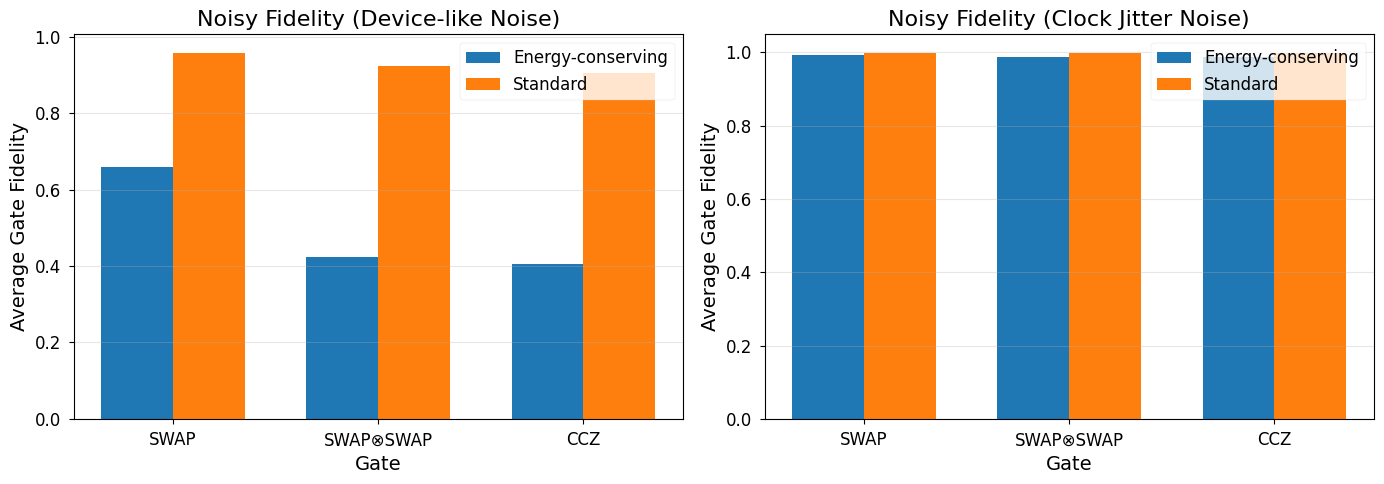

In [7]:
# Plot fidelities
if ancilla_vs_nc:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    gates = [r['gate_name'] for r in ancilla_vs_nc['results']]
    
    # Device noise
    ax = axes[0]
    fid_ec = [r['energy_conserving']['noisy_fidelity_device'] for r in ancilla_vs_nc['results']]
    fid_std = [r['standard']['noisy_fidelity_device'] for r in ancilla_vs_nc['results']]
    
    x = np.arange(len(gates))
    width = 0.35
    
    ax.bar(x - width/2, [f if f else 0 for f in fid_ec], width, label='Energy-conserving')
    ax.bar(x + width/2, [f if f else 0 for f in fid_std], width, label='Standard')
    
    ax.set_xlabel('Gate')
    ax.set_ylabel('Average Gate Fidelity')
    ax.set_title('Noisy Fidelity (Device-like Noise)')
    ax.set_xticks(x)
    ax.set_xticklabels(gates)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Jitter noise
    ax = axes[1]
    fid_ec = [r['energy_conserving']['noisy_fidelity_jitter'] for r in ancilla_vs_nc['results']]
    fid_std = [r['standard']['noisy_fidelity_jitter'] for r in ancilla_vs_nc['results']]
    
    ax.bar(x - width/2, [f if f else 0 for f in fid_ec], width, label='Energy-conserving')
    ax.bar(x + width/2, [f if f else 0 for f in fid_std], width, label='Standard')
    
    ax.set_xlabel('Gate')
    ax.set_ylabel('Average Gate Fidelity')
    ax.set_title('Noisy Fidelity (Clock Jitter Noise)')
    ax.set_xticks(x)
    ax.set_xticklabels(gates)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'ancilla_vs_nonconserving_plots.png', dpi=300, bbox_inches='tight')
    plt.show()

## 3. Native vs Generic Entanglers

This section compares native √iSWAP/XY gates against transpilation to CX-based gates.

In [8]:
# Load results
native_vs_generic = load_results('native_vs_generic-entangler.json')

if native_vs_generic:
    print("Loaded native_vs_generic results")
    print(f"Parameters: {native_vs_generic['parameters']}")

Loaded native_vs_generic results
Parameters: {'n_qubits_list': [3, 4, 5], 'n_trials': 30, 'seed': 1234}


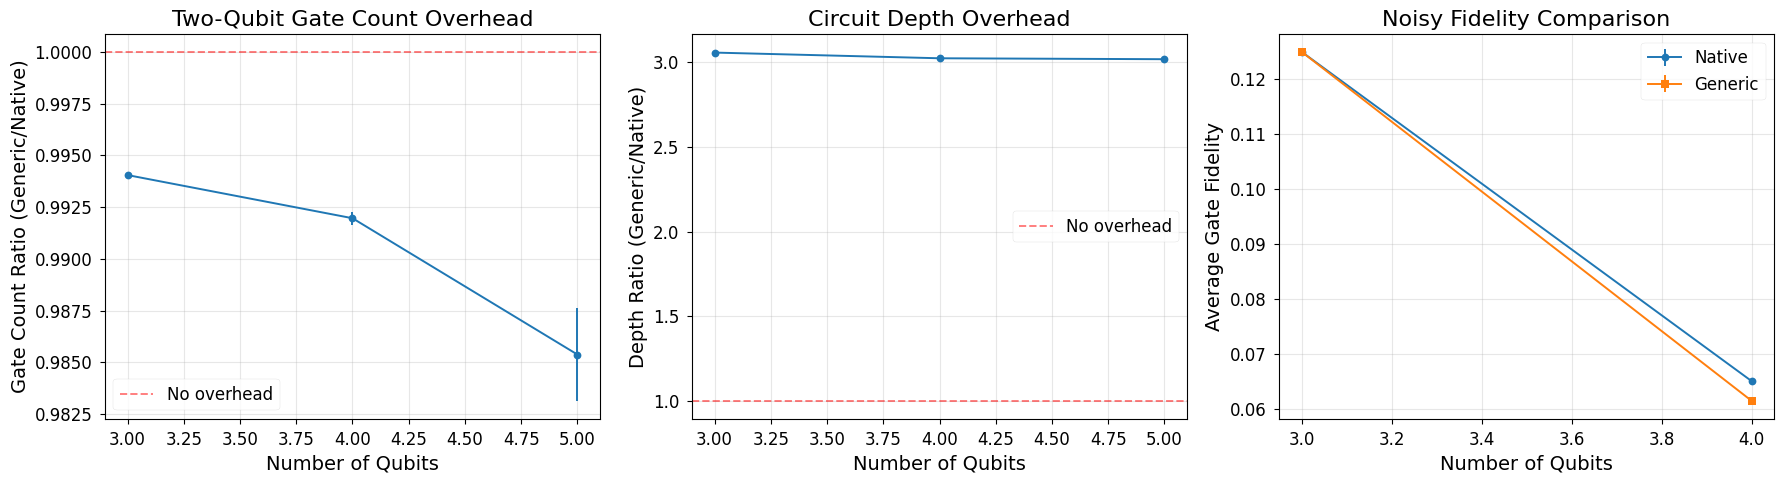

In [9]:
# Plot overhead
if native_vs_generic:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Gate count overhead
    ax = axes[0]
    n_qubits, means, stds = extract_aggregated(native_vs_generic, 'gate_count_ratio', 'overhead')
    
    ax.errorbar(n_qubits, means, yerr=stds, marker='o', capsize=5)
    ax.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='No overhead')
    ax.set_xlabel('Number of Qubits')
    ax.set_ylabel('Gate Count Ratio (Generic/Native)')
    ax.set_title('Two-Qubit Gate Count Overhead')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Depth overhead
    ax = axes[1]
    _, means, stds = extract_aggregated(native_vs_generic, 'depth_ratio', 'overhead')
    
    ax.errorbar(n_qubits, means, yerr=stds, marker='o', capsize=5)
    ax.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='No overhead')
    ax.set_xlabel('Number of Qubits')
    ax.set_ylabel('Depth Ratio (Generic/Native)')
    ax.set_title('Circuit Depth Overhead')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Fidelity comparison
    ax = axes[2]
    _, means_native, stds_native = extract_aggregated(native_vs_generic, 'noisy_fidelity_device', 'native')
    _, means_generic, stds_generic = extract_aggregated(native_vs_generic, 'noisy_fidelity_device', 'generic')
    
    # Filter out None values
    valid_idx = [i for i, (m1, m2) in enumerate(zip(means_native, means_generic)) if m1 is not None and m2 is not None]
    if valid_idx:
        n_qubits_valid = [n_qubits[i] for i in valid_idx]
        means_native_valid = [means_native[i] for i in valid_idx]
        stds_native_valid = [stds_native[i] for i in valid_idx]
        means_generic_valid = [means_generic[i] for i in valid_idx]
        stds_generic_valid = [stds_generic[i] for i in valid_idx]
        
        ax.errorbar(n_qubits_valid, means_native_valid, yerr=stds_native_valid, marker='o', label='Native', capsize=5)
        ax.errorbar(n_qubits_valid, means_generic_valid, yerr=stds_generic_valid, marker='s', label='Generic', capsize=5)
    
    ax.set_xlabel('Number of Qubits')
    ax.set_ylabel('Average Gate Fidelity')
    ax.set_title('Noisy Fidelity Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'native_vs_generic_plots.png', dpi=300, bbox_inches='tight')
    plt.show()

## 4. Angle Discretization

This section studies the impact of discretizing rotation angles to a fixed grid.

In [10]:
# Load results
angle_disc = load_results('angle_discretization.json')

if angle_disc:
    print("Loaded angle_discretization results")
    print(f"Parameters: {angle_disc['parameters']}")

Loaded angle_discretization results
Parameters: {'n_qubits': 3, 'n_trials': 50, 'grids': [0.7853981633974483, 0.39269908169872414, 0.19634954084936207, 0.09817477042468103, 0.04908738521234052], 'seed': 1234}


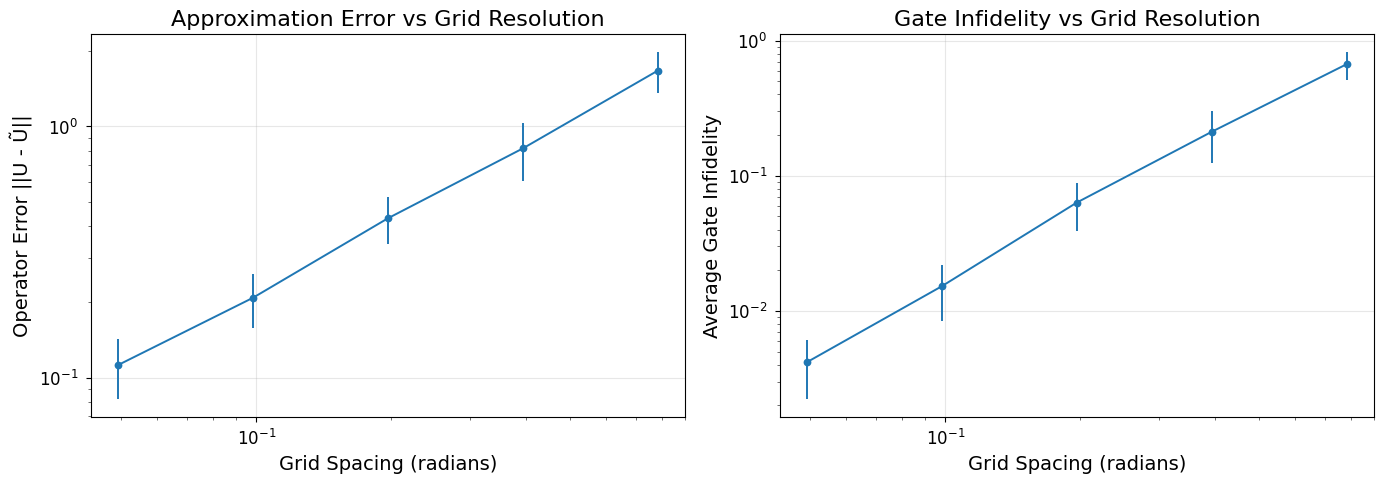

In [11]:
# Plot error vs grid resolution
if angle_disc:
    aggregated = angle_disc['aggregated_statistics']
    grids = sorted([float(k) for k in aggregated.keys()])
    
    # Extract metrics
    operator_errors = [aggregated[str(g)]['operator_error']['mean'] for g in grids]
    operator_errors_std = [aggregated[str(g)]['operator_error']['std'] for g in grids]
    
    gate_infidelities = [aggregated[str(g)]['gate_infidelity']['mean'] for g in grids]
    gate_infidelities_std = [aggregated[str(g)]['gate_infidelity']['std'] for g in grids]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Operator error vs grid
    ax = axes[0]
    ax.errorbar(grids, operator_errors, yerr=operator_errors_std, marker='o', capsize=5)
    ax.set_xlabel('Grid Spacing (radians)')
    ax.set_ylabel('Operator Error ||U - Ũ||')
    ax.set_title('Approximation Error vs Grid Resolution')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    # Gate infidelity vs grid
    ax = axes[1]
    ax.errorbar(grids, gate_infidelities, yerr=gate_infidelities_std, marker='o', capsize=5)
    ax.set_xlabel('Grid Spacing (radians)')
    ax.set_ylabel('Average Gate Infidelity')
    ax.set_title('Gate Infidelity vs Grid Resolution')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'angle_discretization_plots.png', dpi=300, bbox_inches='tight')
    plt.show()

## 5. Geometry/Topology

This section compares all-to-all connectivity vs linear chain topology.

In [12]:
# Load results
geometry = load_results('geometry_topology.json')

if geometry:
    print("Loaded geometry_topology results")
    print(f"Parameters: {geometry['parameters']}")

Loaded geometry_topology results
Parameters: {'n_qubits_list': [3, 4, 5, 6], 'n_trials': 30, 'seed': 1234}


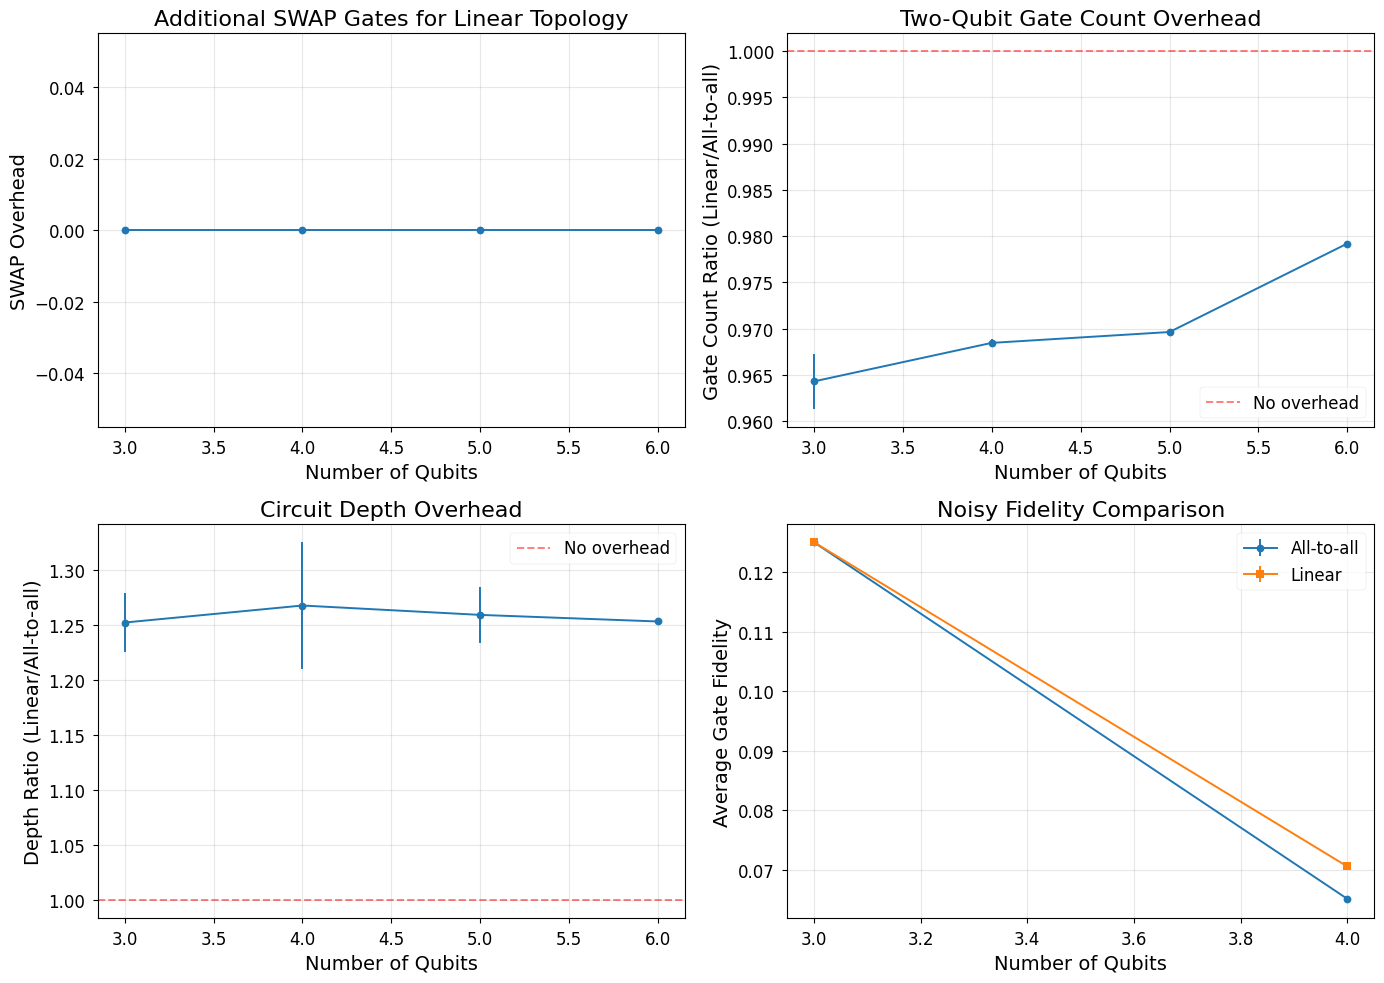

In [13]:
# Plot SWAP overhead and performance
if geometry:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # SWAP overhead
    ax = axes[0, 0]
    n_qubits, means, stds = extract_aggregated(geometry, 'swap_overhead', 'overhead')
    
    ax.errorbar(n_qubits, means, yerr=stds, marker='o', capsize=5)
    ax.set_xlabel('Number of Qubits')
    ax.set_ylabel('SWAP Overhead')
    ax.set_title('Additional SWAP Gates for Linear Topology')
    ax.grid(True, alpha=0.3)
    
    # Gate count overhead
    ax = axes[0, 1]
    _, means, stds = extract_aggregated(geometry, 'gate_count_ratio', 'overhead')
    
    ax.errorbar(n_qubits, means, yerr=stds, marker='o', capsize=5)
    ax.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='No overhead')
    ax.set_xlabel('Number of Qubits')
    ax.set_ylabel('Gate Count Ratio (Linear/All-to-all)')
    ax.set_title('Two-Qubit Gate Count Overhead')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Depth overhead
    ax = axes[1, 0]
    _, means, stds = extract_aggregated(geometry, 'depth_ratio', 'overhead')
    
    ax.errorbar(n_qubits, means, yerr=stds, marker='o', capsize=5)
    ax.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='No overhead')
    ax.set_xlabel('Number of Qubits')
    ax.set_ylabel('Depth Ratio (Linear/All-to-all)')
    ax.set_title('Circuit Depth Overhead')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Fidelity comparison
    ax = axes[1, 1]
    _, means_all, stds_all = extract_aggregated(geometry, 'noisy_fidelity', 'all_to_all')
    _, means_linear, stds_linear = extract_aggregated(geometry, 'noisy_fidelity', 'linear')
    
    # Filter out None values
    valid_idx = [i for i, (m1, m2) in enumerate(zip(means_all, means_linear)) if m1 is not None and m2 is not None]
    if valid_idx:
        n_qubits_valid = [n_qubits[i] for i in valid_idx]
        means_all_valid = [means_all[i] for i in valid_idx]
        stds_all_valid = [stds_all[i] for i in valid_idx]
        means_linear_valid = [means_linear[i] for i in valid_idx]
        stds_linear_valid = [stds_linear[i] for i in valid_idx]
        
        ax.errorbar(n_qubits_valid, means_all_valid, yerr=stds_all_valid, marker='o', label='All-to-all', capsize=5)
        ax.errorbar(n_qubits_valid, means_linear_valid, yerr=stds_linear_valid, marker='s', label='Linear', capsize=5)
    
    ax.set_xlabel('Number of Qubits')
    ax.set_ylabel('Average Gate Fidelity')
    ax.set_title('Noisy Fidelity Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'geometry_topology_plots.png', dpi=300, bbox_inches='tight')
    plt.show()

## Summary

### Key Findings

1. **Symmetry-preserving decomposition**:
   - Energy-conserving decomposition eliminates non-conserving gates
   - May have overhead in 2q gate count due to ancilla usage
   - Can achieve better or comparable fidelity under certain noise models

2. **Ancilla vs non-conserving implementations**:
   - Ancilla-based implementations use additional qubits but preserve energy conservation
   - Trade-off between gate count and maintaining symmetry
   - Performance depends on noise characteristics

3. **Native vs generic entanglers**:
   - Significant overhead when transpiling to generic CX basis
   - Native √iSWAP/XY gates are more efficient when available
   - Fidelity degrades with additional gate decompositions

4. **Angle discretization**:
   - Error decreases exponentially with finer grid resolution
   - Trade-off between approximation accuracy and available gate set
   - Relevant for fault-tolerant implementations

5. **Geometry/topology**:
   - Linear topology requires SWAP overhead for non-adjacent interactions
   - Overhead grows with system size
   - All-to-all connectivity provides significant advantage for energy-conserving circuits

### Conclusion

The energy-conserving decomposition provides a valuable approach for implementing unitaries on hardware with specific symmetries. The choice of implementation depends on:
- Available native gates (√iSWAP vs CX)
- Connectivity topology (all-to-all vs constrained)
- Noise characteristics (coherent vs incoherent)
- Availability of ancilla qubits
- Required precision (exact vs approximate)